In [1]:
from datascience import *
import numpy as np
path_data = 'data/'
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


# 회귀선 (The Regression Line)
상관 계수 $r$은 산점도의 점들이 직선 주위에 얼마나 모여 있는지만 측정하는 것이 아닙니다. 또한 점들이 모여 있는 직선을 식별하는 데도 도움이 됩니다. 이 섹션에서는 골턴(Galton)과 피어슨(Pearson)이 그 선을 발견하기 위해 택했던 경로를 되짚어 볼 것입니다.

우리가 보았듯이, 부모와 성인 자녀의 키에 대한 데이터 세트는 두 변수 사이의 선형 연관성을 나타냅니다. 부모 평균 키를 기반으로 한 자녀 키의 예측이 대략 직선을 따를 때 선형성이 확인되었습니다.

In [3]:
original = Table.read_table(path_data + 'family_heights.csv')

heights = Table().with_columns(
    'MidParent', original.column('midparentHeight'),
    'Child', original.column('childHeight')
    )

In [4]:
def predict_child(mpht):
    """Return a prediction of the height of a child
    whose parents have a midparent height of mpht.

    The prediction is the average height of the children
    whose midparent height is in the range mpht plus or minus 0.5 inches.
    """

    close_points = heights.where('MidParent', are.between(mpht-0.5, mpht + 0.5))
    return close_points.column('Child').mean()

In [5]:
heights_with_predictions = heights.with_column(
    'Prediction', heights.apply(predict_child, 'MidParent')
    )

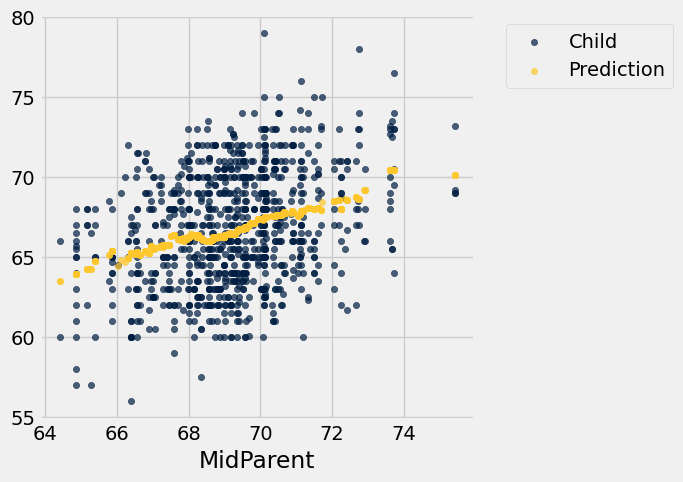

In [6]:
heights_with_predictions.scatter('MidParent')

## 표준 단위로 측정하기

이 선을 식별할 수 있는 방법을 찾을 수 있는지 봅시다. 먼저, 선형 연관성은 측정 단위에 의존하지 않는다는 점에 주목하십시오 – 두 변수 모두 표준 단위로 측정하는 것이 좋겠습니다.

In [7]:
def standard_units(xyz):
    "Convert any array of numbers to standard units."
    return (xyz - np.mean(xyz))/np.std(xyz)

In [8]:
heights_SU = Table().with_columns(
    'MidParent SU', standard_units(heights.column('MidParent')),
    'Child SU', standard_units(heights.column('Child'))
)
heights_SU

MidParent SU,Child SU
3.45465,1.80416
3.45465,0.686005
3.45465,0.630097
3.45465,0.630097
2.47209,1.88802
2.47209,1.60848
2.47209,-0.348285
2.47209,-0.348285
1.58389,1.18917
1.58389,0.350559


이 척도에서도 이전과 똑같이 예측을 계산할 수 있습니다. 하지만 먼저 "가까운" 점에 대한 이전 정의를 새로운 척도의 값으로 변환하는 방법을 알아내야 합니다. 우리는 부모 평균 키가 서로 0.5인치 이내이면 "가깝다"고 말했습니다. 표준 단위는 거리(distance)를 표준 편차(SD) 단위로 측정하므로, 부모 평균 키의 몇 SD가 0.5인치에 해당하는지 알아내야 합니다.

부모 평균 키의 1 SD는 약 1.8인치입니다. 따라서 0.5인치는 약 0.28 SD입니다.

In [9]:
sd_midparent = np.std(heights.column(0))
sd_midparent

1.8014050969207571

In [10]:
0.5/sd_midparent

0.27756111096536701

이제 표준 단위 척도에서 예측을 수행하도록 예측 함수를 수정할 준비가 되었습니다. 변경된 것은 표준 단위 값 테이블을 사용하고 위와 같이 "가까움"을 정의한다는 것뿐입니다.

In [11]:
def predict_child_su(mpht_su):
    """Return a prediction of the height (in standard units) of a child
    whose parents have a midparent height of mpht_su in standard units.
    """
    close = 0.5/sd_midparent
    close_points = heights_SU.where('MidParent SU', are.between(mpht_su-close, mpht_su + close))
    return close_points.column('Child SU').mean()

In [12]:
heights_with_su_predictions = heights_SU.with_column(
    'Prediction SU', heights_SU.apply(predict_child_su, 'MidParent SU')
    )

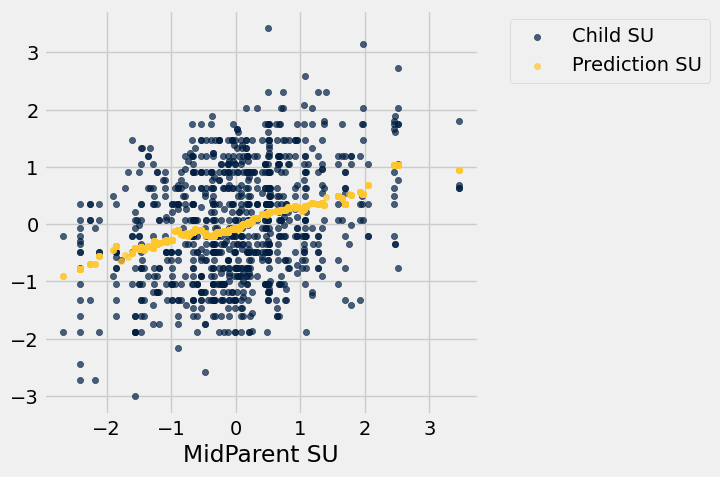

In [13]:
heights_with_su_predictions.scatter('MidParent SU')

이 플롯은 원래 척도로 그려진 플롯과 똑같이 보입니다. 축의 숫자만 바뀌었습니다. 이는 표준 단위로 작업하는 것만으로도 예측 과정을 이해할 수 있음을 확인시켜 줍니다.

## 표준 단위에서 선 식별하기
위의 산점도는 *럭비공(football)* 모양입니다 – 즉, 미식축구 공처럼 대략 타원형입니다. 모든 산점도가 럭비공 모양인 것은 아니며, 선형 연관성을 보여주는 산점도조차도 항상 그렇지는 않습니다. 하지만 이 섹션에서는 럭비공 모양의 산점도만 다룰 것입니다. 다음 섹션에서는 분석을 다른 모양의 플롯으로 일반화할 것입니다.

다음은 두 변수가 모두 표준 단위로 측정된 럭비공 모양의 산점도입니다. 45도 선은 빨간색으로 표시됩니다.

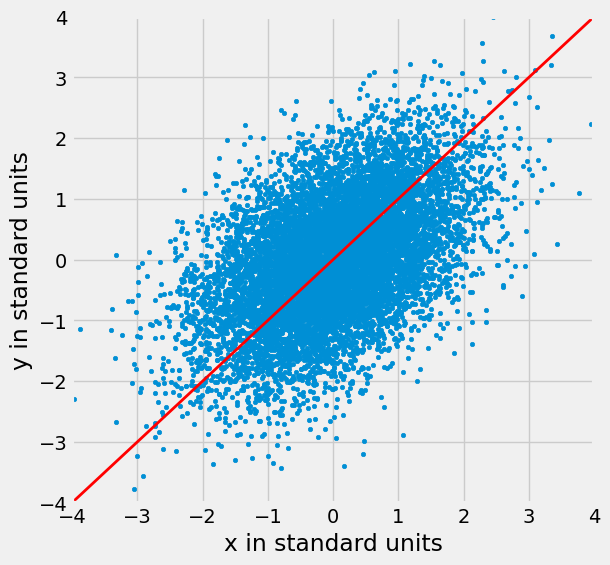

In [14]:
r = 0.5
x_demo = np.random.normal(0, 1, 10000)
z_demo = np.random.normal(0, 1, 10000)
y_demo = r*x_demo + np.sqrt(1 - r**2)*z_demo
plots.figure(figsize=(6,6))
plots.xlim(-4, 4)
plots.ylim(-4, 4)
plots.scatter(x_demo, y_demo, s=10)
#plots.plot([-4, 4], [-4*0.6,4*0.6], color='g', lw=2)
plots.plot([-4,4],[-4,4], color='r', lw=2)
#plots.plot([1.5,1.5], [-4,4], color='k', lw=2)
plots.xlabel('x in standard units')
plots.ylabel('y in standard units');

그러나 45도 선은 수직 띠의 중심을 골라내는 선이 아닙니다. 아래 그림에서 1.5 표준 단위의 수직선이 검은색으로 표시된 것을 보면 알 수 있습니다. 검은색 선 근처의 산점도 점들은 모두 대략 -2에서 3 범위의 높이를 가집니다. 빨간색 선은 중심을 골라내기에는 너무 높습니다.

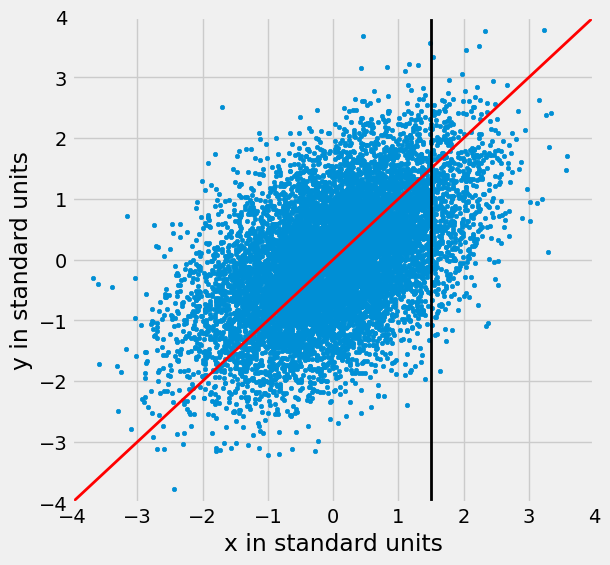

In [15]:
r = 0.5
x_demo = np.random.normal(0, 1, 10000)
z_demo = np.random.normal(0, 1, 10000)
y_demo = r*x_demo + np.sqrt(1 - r**2)*z_demo
plots.figure(figsize=(6,6))
plots.xlim(-4, 4)
plots.ylim(-4, 4)
plots.scatter(x_demo, y_demo, s=10)
#plots.plot([-4, 4], [-4*0.6,4*0.6], color='g', lw=2)
plots.plot([-4,4],[-4,4], color='r', lw=2)
plots.plot([1.5,1.5], [-4,4], color='k', lw=2)
plots.xlabel('x in standard units')
plots.ylabel('y in standard units');

따라서 45도 선은 "평균의 그래프"가 아닙니다. 그 선은 아래에 표시된 녹색 선입니다.

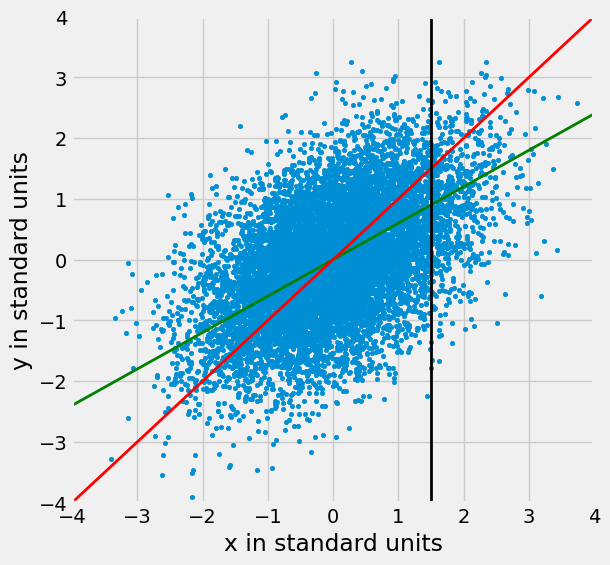

In [16]:
r = 0.5
x_demo = np.random.normal(0, 1, 10000)
z_demo = np.random.normal(0, 1, 10000)
y_demo = r*x_demo + np.sqrt(1 - r**2)*z_demo
plots.figure(figsize=(6,6))
plots.xlim(-4, 4)
plots.ylim(-4, 4)
plots.scatter(x_demo, y_demo, s=10)
plots.plot([-4, 4], [-4*0.6,4*0.6], color='g', lw=2)
plots.plot([-4,4],[-4,4], color='r', lw=2)
plots.plot([1.5,1.5], [-4,4], color='k', lw=2)
plots.xlabel('x in standard units')
plots.ylabel('y in standard units');

두 선 모두 원점 (0, 0)을 통과합니다. 녹색 선은 (적어도 대략적으로) 수직 띠의 중심을 통과하며 빨간색 45도 선보다 *더 평평합니다*.

45도 선의 기울기는 1입니다. 따라서 녹색 "평균의 그래프" 선의 기울기는 양수이지만 1보다 작은 값입니다.

그 값은 무엇일까요? 짐작하셨겠지만 – 바로 $r$입니다.

## 표준 단위에서의 회귀선
녹색 "평균의 그래프" 선은 곧 설명할 이유로 *회귀선(regression line)*이라고 불립니다. 하지만 먼저, 서로 다른 $r$ 값을 가진 럭비공 모양의 산점도를 시뮬레이션하고 선이 어떻게 변하는지 살펴봅시다. 각 경우에 비교를 위해 빨간색 45도 선이 그려져 있습니다.

시뮬레이션을 수행하는 함수는 `regression_line`이며 $r$을 인수로 받습니다.

In [17]:

def regression_line(r):
    x = np.random.normal(0, 1, 10000)
    z = np.random.normal(0, 1, 10000)
    y = r*x + (np.sqrt(1-r**2))*z
    plots.figure(figsize=(6, 6))
    plots.xlim(-4, 4)
    plots.ylim(-4, 4)
    plots.scatter(x, y)
    plots.plot([-4, 4], [-4*r,4*r], color='g', lw=2)
    if r >= 0:
        plots.plot([-4,4],[-4,4], lw=2, color='r')
    else:
        plots.plot([-4,4], [4,-4], lw=2, color='r')

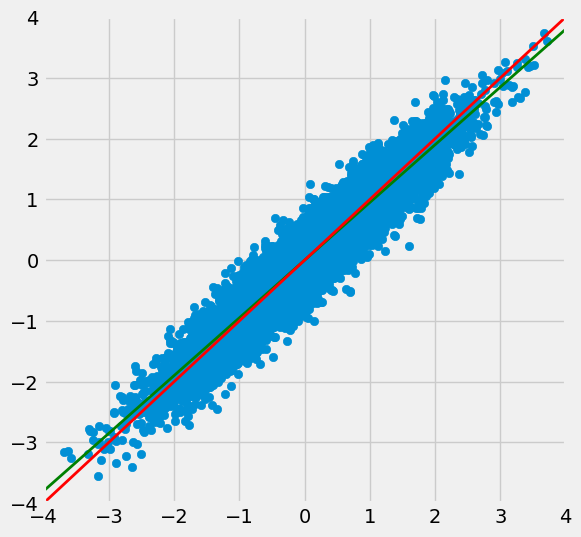

In [18]:
regression_line(0.95)

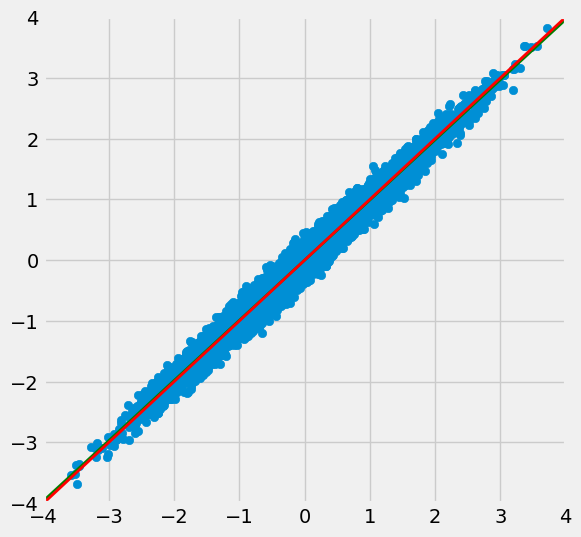

In [19]:
regression_line(0.99)

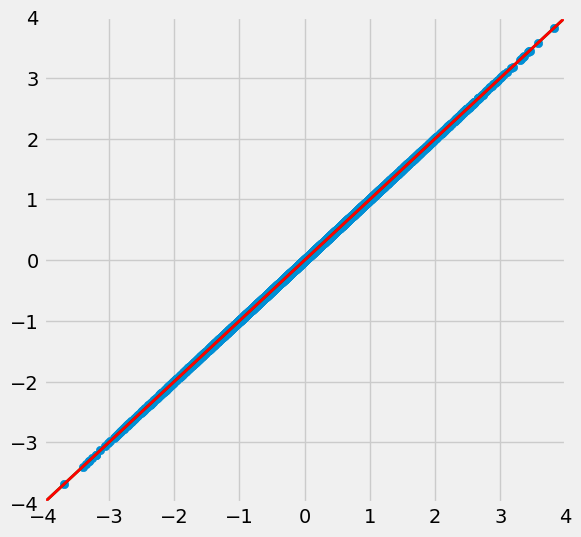

In [20]:
regression_line(1.0)

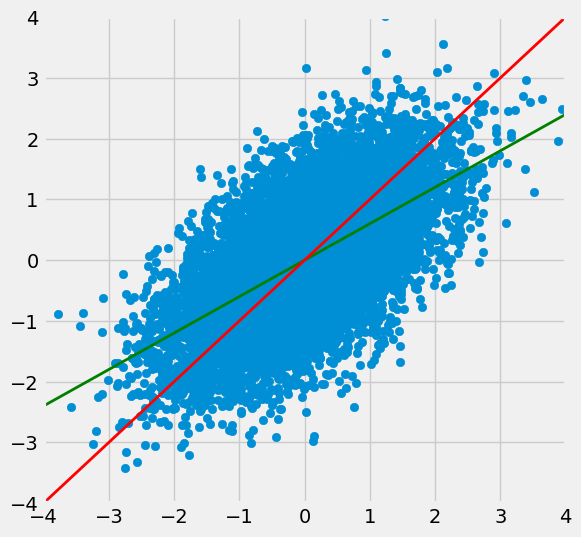

In [21]:
regression_line(0.6)

$r$이 1에 가까우면 산점도, 45도 선, 회귀선이 모두 서로 매우 가깝습니다. 그러나 $r$의 값이 더 적당하면 회귀선이 눈에 띄게 더 평평합니다.

## 회귀 효과 (The Regression Effect)
예측 측면에서 이는 부모 평균 키가 1.5 표준 단위인 부모의 경우 자녀 키에 대한 예측이 1.5 표준 단위보다 다소 *작다는* 것을 의미합니다. 부모 평균 키가 2 표준 단위라면 자녀 키는 2 표준 단위보다 다소 작을 것으로 예측합니다.

즉, 우리는 자녀가 부모보다 평균에 다소 더 가까울 것이라고 예측합니다. 이를 "평균으로의 회귀(regression to the mean)"라고 하며 *회귀(regression)*라는 이름이 생긴 유래입니다.

평균으로의 회귀는 부모 평균 키가 평균보다 작을 때도 작용합니다. 부모 평균 키가 평균보다 작은 자녀는 평균적으로 해당 세대에 비해 키가 다소 더 큰 것으로 나타났습니다.

일반적으로 한 변수에서 평균에서 멀리 떨어진 개체는 다른 변수에서는 평균에서 그만큼 멀지 않을 것으로 예상됩니다. 이를 *회귀 효과(regression effect)*라고 합니다.

회귀 효과는 평균에 대한 진술임을 명심하십시오. 예를 들어, 부모 평균 키가 1.5 표준 단위인 모든 자녀를 취하면 이 자녀들의 평균 키는 1.5 표준 단위보다 다소 작다는 것을 의미합니다. 이 모든 자녀의 키가 1.5 표준 단위보다 다소 작다는 말은 아닙니다. 일부는 더 크고 일부는 더 작을 것입니다. 이 높이들의 *평균*이 1.5 표준 단위보다 작을 것입니다.

## 회귀선의 방정식
회귀에서는 한 변수(우리가 $x$라고 부를 것)의 값을 사용하여 다른 변수(우리가 $y$라고 부를 것)의 값을 예측합니다. 변수 $x$와 $y$가 표준 단위로 측정될 때, $x$를 기반으로 $y$를 예측하기 위한 회귀선은 기울기 $r$을 가지며 원점을 통과합니다. 따라서 회귀선의 방정식은 다음과 같이 쓸 수 있습니다:

$$
\mbox{estimate of }y ~=~ r \cdot x ~~~
\mbox{when both variables are measured in standard units}
$$

데이터의 원래 단위에서는 다음과 같습니다:

$$
\frac{\mbox{estimate of}~y ~-~\mbox{average of}~y}{\mbox{SD of}~y}
~=~ r \times
\frac{\mbox{the given}~x ~-~\mbox{average of}~x}{\mbox{SD of}~x}
$$


![regline](../../../images/regline.png)

원래 단위에서의 회귀선의 기울기와 절편은 위 다이어그램에서 유도할 수 있습니다.

$$
\mathbf{\mbox{slope of the regression line}} ~=~ r \cdot
\frac{\mbox{SD of }y}{\mbox{SD of }x}
$$

$$
\mathbf{\mbox{intercept of the regression line}} ~=~
\mbox{average of }y ~-~ \mbox{slope} \cdot \mbox{average of }x
$$

아래 세 함수는 상관 계수, 기울기, 절편을 계산합니다. 이 모든 함수는 테이블 이름, $x$가 포함된 열의 레이블, $y$가 포함된 열의 레이블 등 세 가지 인수를 받습니다.

In [22]:
def correlation(t, label_x, label_y):
    return np.mean(standard_units(t.column(label_x))*standard_units(t.column(label_y)))

def slope(t, label_x, label_y):
    r = correlation(t, label_x, label_y)
    return r*np.std(t.column(label_y))/np.std(t.column(label_x))

def intercept(t, label_x, label_y):
    return np.mean(t.column(label_y)) - slope(t, label_x, label_y)*np.mean(t.column(label_x))

## 데이터 단위에서의 회귀선
부모 평균 키와 자녀 키 사이의 상관관계는 0.32입니다.

In [23]:
family_r = correlation(heights, 'MidParent', 'Child')
family_r

0.32094989606395924

우리는 또한 부모 평균 키를 기반으로 자녀 키를 예측하기 위한 회귀선의 방정식을 찾을 수 있습니다.

In [24]:
family_slope = slope(heights, 'MidParent', 'Child')
family_intercept = intercept(heights, 'MidParent', 'Child')
family_slope, family_intercept

(0.63736089696947895, 22.636240549589751)

회귀선의 방정식은 다음과 같습니다.

$$
\mbox{estimate of child's height} ~=~ 0.64 \cdot \mbox{midparent height} ~+~ 22.64
$$

이것은 *회귀 방정식(regression equation)*이라고도 합니다. 회귀 방정식의 주된 용도는 $x$를 기반으로 $y$를 예측하는 것입니다.

예를 들어, 70.48인치의 부모 평균 키에 대해 회귀 방정식은 자녀의 키가 67.56인치가 될 것으로 예측합니다.

In [25]:
family_slope * 70.48 + family_intercept

67.557436567998622

70.48에 가까운 부모 평균 키를 가진 모든 자녀의 평균 키를 취하여 생성한 우리의 원래 예측은 꽤 가깝게 나왔습니다: 회귀선의 예측인 67.55인치에 비해 67.63인치입니다.

In [28]:
heights_with_predictions.where('MidParent', are.equal_to(70.48)).show(10)

MidParent,Child,Prediction
70.48,74,67.6342
70.48,70,67.6342
70.48,68,67.6342
70.48,67,67.6342
70.48,67,67.6342
70.48,66,67.6342
70.48,63.5,67.6342
70.48,63,67.6342


다음은 테이블의 모든 행과 우리의 원래 예측, 그리고 자녀 키에 대한 새로운 회귀 예측입니다.

In [29]:
heights_with_predictions = heights_with_predictions.with_column(
    'Regression Prediction', family_slope * heights.column('MidParent') + family_intercept
)
heights_with_predictions

MidParent,Child,Prediction,Regression Prediction
75.43,73.2,70.1,70.7124
75.43,69.2,70.1,70.7124
75.43,69,70.1,70.7124
75.43,69,70.1,70.7124
73.66,73.5,70.4158,69.5842
73.66,72.5,70.4158,69.5842
73.66,65.5,70.4158,69.5842
73.66,65.5,70.4158,69.5842
72.06,71,68.5025,68.5645
72.06,68,68.5025,68.5645


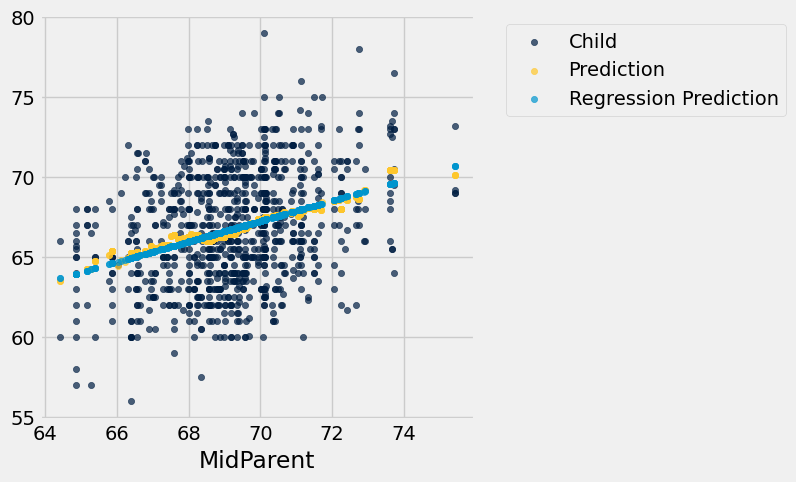

In [30]:
heights_with_predictions.scatter('MidParent')

회색 점들은 모두 회귀선 위에 있는 회귀 예측을 보여줍니다. 선이 금색 평균 그래프에 얼마나 가까운지 주목하십시오. 이 데이터의 경우 회귀선은 수직 띠의 중심을 잘 근사합니다.

## 적합값 (Fitted Values)
예측값들은 모두 선 위에 있으며 "적합값(fitted values)"으로 알려져 있습니다. `fit` 함수는 테이블 이름과 $x$, $y$의 레이블을 받아 산점도의 각 점에 대한 하나의 적합값으로 구성된 배열을 반환합니다.

In [31]:
def fit(table, x, y):
    """Return the height of the regression line at each x value."""
    a = slope(table, x, y)
    b = intercept(table, x, y)
    return a * table.column(x) + b

위의 그래프보다 아래 그래프에서 선을 보기가 더 쉽습니다.

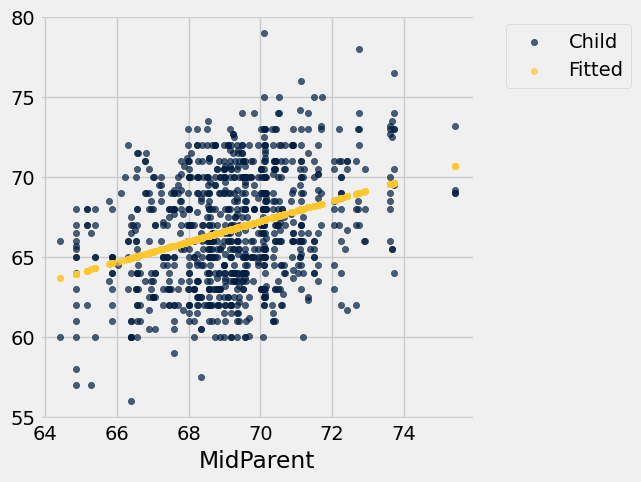

In [32]:
heights.with_column('Fitted', fit(heights, 'MidParent', 'Child')).scatter('MidParent')

선을 그리는 또 다른 방법은 Table 메서드 `scatter`와 함께 `fit_line=True` 옵션을 사용하는 것입니다.

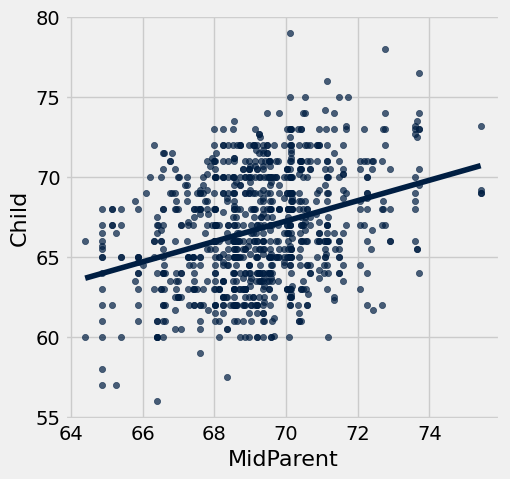

In [33]:
heights.scatter('MidParent', fit_line=True)

## 기울기의 측정 단위
기울기는 비율이며, 측정 단위를 잠시 살펴보는 것은 가치가 있습니다. 우리의 예는 병원 시스템에서 출산한 어머니에 대한 친숙한 데이터 세트에서 가져왔습니다. 임신 중 체중 대 키의 산점도는 너무 많은 게임에 사용된 럭비공처럼 보이지만, 적합선을 그리는 것을 정당화할 수 있을 만큼 충분히 럭비공에 가깝습니다. 나중 섹션에서 이러한 정당화를 더 공식적으로 만드는 방법을 볼 것입니다.

In [34]:
baby = Table.read_table(path_data + 'baby.csv')

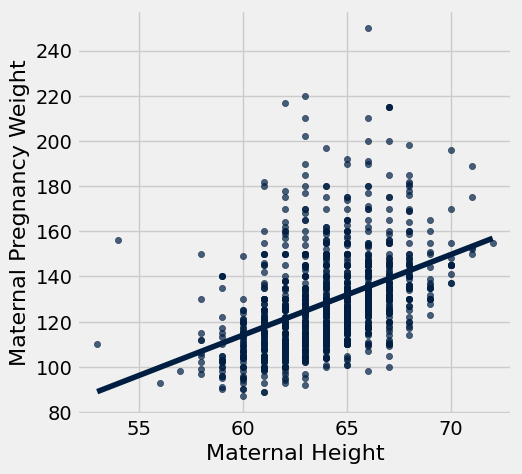

In [35]:
baby.scatter('Maternal Height', 'Maternal Pregnancy Weight', fit_line=True)

In [36]:
slope(baby, 'Maternal Height', 'Maternal Pregnancy Weight')

3.5728462592750558

회귀선의 기울기는 **인치당 3.57파운드**입니다. 이는 키가 1인치 차이 나는 두 여성에 대해 임신 중 체중 예측이 3.57파운드 차이가 날 것임을 의미합니다. 다른 여성보다 2인치 더 큰 여성의 경우, 임신 중 체중 예측은 더 작은 여성에 대한 예측보다

$$
2 \times 3.57 ~=~ 7.14
$$

파운드 더 많을 것입니다.

키가 가장 가까운 인치로 반올림되었기 때문에 산점도의 연속적인 수직 띠가 1인치 떨어져 있다는 점에 주목하십시오. 기울기에 대해 생각하는 또 다른 방법은 키가 1인치 차이 나는 두 그룹의 여성에 해당하는 두 개의 연속적인 띠(반드시 1인치 떨어져 있음)를 취하는 것입니다. 인치당 3.57파운드의 기울기는 더 큰 그룹의 평균 임신 체중이 더 작은 그룹보다 약 3.57파운드 더 많다는 것을 의미합니다.


## 예제

우리의 목표가 회귀 모델과 일치하는 표본을 사용하여 무게를 기반으로 바셋 하운드의 키를 추정하는 것이라고 가정해 봅시다. 관찰된 상관 계수 $r$이 0.5이고 두 변수에 대한 요약 통계가 아래 표와 같다고 가정합니다:

|       |**average**    |**SD**     |   
|------:|:-------------:|:---------:|
|height |14 inches      |2 inches   |
|weight |50 pounds      |5 pounds   |

회귀선의 방정식을 계산하려면 기울기와 절편이 필요합니다.

$$
\mbox{slope} ~=~ \frac{r \cdot \mbox{SD of }y}{\mbox{SD of }x} ~=~
\frac{0.5 \cdot 2 \mbox{ inches}}{5 \mbox{ pounds}} ~=~ 0.2 ~\mbox{inches per pound}
$$


$$
\mbox{intercept} ~=~ \mbox{average of }y - \mbox{slope}\cdot \mbox{average of } x
~=~ 14 \mbox{ inches} ~-~ 0.2 \mbox{ inches per pound} \cdot 50 \mbox{ pounds}
~=~ 4 \mbox{ inches}
$$

회귀선의 방정식을 사용하면 주어진 무게(파운드)를 기반으로 추정 키(인치)를 계산할 수 있습니다:

$$
\mbox{estimated height} ~=~ 0.2 \cdot \mbox{given weight} ~+~ 4
$$

선의 기울기는 무게가 단위 증가할 때 추정 키의 증가를 측정합니다. 기울기는 양수이며, 이것이 바셋 하운드가 살이 찌면 키가 커진다고 생각한다는 의미가 아니라는 점에 유의하는 것이 중요합니다. 기울기는 무게가 1파운드 차이 나는 두 그룹의 개들의 평균 키 차이를 반영합니다. 구체적으로, 무게가 $w$ 파운드인 개 그룹과 $w+1$ 파운드인 그룹을 고려하십시오. 두 번째 그룹은 평균적으로 0.2인치 더 큰 것으로 추정됩니다. 이것은 표본의 모든 $w$ 값에 대해 사실입니다.

일반적으로 회귀선의 기울기는 $x$가 단위 증가할 때 $y$의 평균 증가로 해석할 수 있습니다. 기울기가 음수이면 $x$가 단위 증가할 때 $y$의 평균이 감소한다는 점에 유의하십시오.

## 맺음말
비록 우리가 회귀 방정식의 수학적 기초를 확립하지는 않겠지만, 산점도가 럭비공 모양일 때 꽤 좋은 예측을 제공한다는 것을 알 수 있습니다. 산점도의 모양이 무엇이든 동일한 방정식이 모든 직선 중에서 "최고"를 제공한다는 것은 놀라운 수학적 사실입니다. 그것이 다음 섹션의 주제입니다.